In [1]:
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import pandas as pd
import pingouin as pg
import seaborn as sns


import TwoPUtils as tpu
import STX3KO_analyses as stx

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice

plt.rcParams['pdf.fonttype']=42


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [101]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig1_licks')
figdir.mkdir(exist_ok=True, parents=True)

In [102]:
rows = []
x = np.arange(-10,3)
for (cond, mice) in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    for day in range(6):
        print(day)
        for mouse in mice:
            print(mouse)
            sess = stx.utilities.load_vr_day(mouse, day, trial_mat_keys = ('nonconsum_licks','licks_sum'),verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/')

            bin_edges = sess.trial_matrices['bin_edges']
            right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            if sess.novel_arm==-1:
                rzone_nov = left_rzone_front
                rzone_fam = right_rzone_front
            else:
                rzone_nov = right_rzone_front
                rzone_fam = left_rzone_front

            for ttype in ('fam', 'nov'):
                
                if ttype == 'nov':
                    trial_mask = sess.trial_info["LR"] == sess.novel_arm
                    rzone = rzone_nov
                else:
                    trial_mask = sess.trial_info["LR"] != sess.novel_arm
                    rzone = rzone_fam

                
                licks = sess.trial_matrices['licks_sum'][trial_mask,:]
                rzone_licks = np.nanmean(licks[:,rzone-5:rzone+1], axis=0).sum()
                rzone_lick_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)

                rows.append({'cond': cond,
                             'mouse': mouse,
                             'day': day,
                             'ttype': ttype,
                             'rzone_licks': rzone_licks,
                             'rzone_licks_plot_vec': rzone_lick_plot_vec,
                             })
df = pd.DataFrame(rows)
                
                

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9


In [103]:
df.head()

,cond,mouse,day,ttype,rzone_licks,rzone_licks_plot_vec
0,ctrl,4467331.1,0,fam,13.825000,"[0.275, 0.30833333333333335, 0.225, 0.45, 0.47..."
1,ctrl,4467331.1,0,nov,7.631579,"[0.05263157894736842, 0.05263157894736842, 0.0..."
2,ctrl,4467331.2,0,fam,26.355372,"[1.0330578512396693, 1.4297520661157024, 1.900..."
3,ctrl,4467331.2,0,nov,36.315789,"[3.1578947368421053, 4.105263157894737, 3.9473..."
4,ctrl,4467332.1,0,fam,39.440678,"[1.076271186440678, 1.152542372881356, 1.34745..."


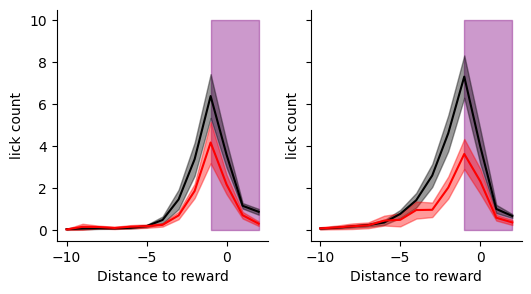

In [104]:
day = 5

x = np.arange(-10,3)
fig, ax =plt.subplots(1,2, sharey=True, sharex=True, figsize=[6,3])


ttype = 'fam'
cond = 'ctrl'
for cond, color in zip(('ctrl', 'ko'), ('black','red')):
    for i, ttype in enumerate(('fam', 'nov')):

        mask = (df['cond']==cond) * (df['day']==day) * (df['ttype']==ttype)

        licks = np.vstack(df.loc[mask,'rzone_licks_plot_vec'].values)


        mu, sem = np.nanmean(licks, axis=0), sp.stats.sem(licks, axis=0, nan_policy='omit')
        ax[i].plot(x, mu, color=color)
        ax[i].fill_between(x, mu-sem, mu+sem, color=color, alpha=.4)

for a in ax.flatten():
    a.fill_betweenx([0,10], -1, 2, alpha=.4, color='purple', zorder=-10)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

    a.set_ylabel('lick count')
    a.set_xlabel('Distance to reward')
fig.savefig(figdir / f"licks_v_position_day{day}.pdf")

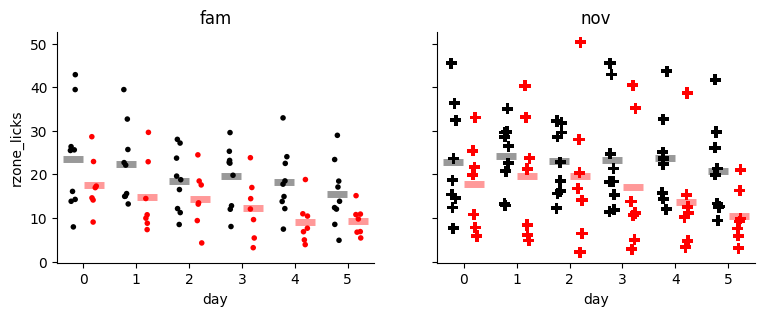

In [105]:


fig,ax = plt.subplots(1,2, figsize=[9,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_licks',
                hue='cond', 
                hue_order=('ctrl', 'ko'), 
                palette=['black', 'red'],
                dodge=True,
                ax=ax[i], marker = marker, s=s,
                legend=False)
    


    sns.pointplot(data=df.loc[df['ttype']==nov,:],
              x='day',
              y='rzone_licks',
              errorbar=None,
              hue='cond',
              hue_order = ['ctrl', 'ko'],
              dodge = .4,
              palette = ['black', 'red'],
              ax=ax[i],
              linestyles="none",
              marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
              )
    ax[i].set_title(nov)

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)


fig.savefig(figdir / "licks_summary.pdf")


In [94]:
df['rzone_licks_rank'] = df['rzone_licks'].rank()




In [95]:
aov = pg.mixed_anova(data = df.loc[df['ttype']=='fam'], subject='mouse', 
                     within='day', between='cond', dv='rzone_licks_rank')

aov

,Source,SS,DF1,DF2,MS,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,cond,40555.982515,1,14,40555.982515,5.263660,0.037758,NaN,0.273243,NaN,NaN,NaN,NaN
1,day,25691.263021,5,70,5138.252604,5.084762,0.000493,0.004084,0.266430,0.591396,False,0.142551,0.032098
2,Interaction,4409.564360,5,70,881.912872,0.872732,0.503969,NaN,0.058680,NaN,NaN,NaN,NaN


In [96]:
aov = pg.mixed_anova(data = df.loc[df['ttype']=='nov'], subject='mouse', 
                     within='day', between='cond', dv='rzone_licks_rank')

aov

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,44919.445478,1,14,44919.445478,3.167106,0.096844,0.184487,NaN
1,day,13057.888021,5,70,2611.577604,2.675870,0.028546,0.160464,0.66772
2,Interaction,5080.698619,5,70,1016.139724,1.041155,0.400534,0.069220,NaN


In [97]:
pg.pairwise_tests(data=df.loc[df['ttype']=='fam'], 
                  subject='mouse', 
                  within='day', 
                  between='cond', 
                  dv='rzone_licks', 
                  parametric=False, padjust='holm', within_first=True)

,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,NaN,39.0,two-sided,0.143860,0.560669,holm,0.191402
1,day,-,0,2,True,False,NaN,29.0,two-sided,0.044312,0.443115,holm,0.489025
2,day,-,0,3,True,False,NaN,31.0,two-sided,0.057678,0.461426,holm,0.502716
3,day,-,0,4,True,False,NaN,15.0,two-sided,0.004181,0.058533,holm,0.729501
4,day,-,0,5,True,False,NaN,13.0,two-sided,0.002686,0.040283,holm,0.936808
5,day,-,1,2,True,False,NaN,37.0,two-sided,0.116669,0.560669,holm,0.288303
6,day,-,1,3,True,False,NaN,36.0,two-sided,0.104584,0.560669,holm,0.310818
7,day,-,1,4,True,False,NaN,22.0,two-sided,0.015503,0.201538,holm,0.549059
8,day,-,1,5,True,False,NaN,22.0,two-sided,0.015503,0.201538,holm,0.757284
9,day,-,2,3,True,False,NaN,52.0,two-sided,0.433197,0.866394,holm,0.041659


In [98]:
pg.pairwise_tests(data=df.loc[df['ttype']=='nov'], 
                  subject='mouse', 
                  within='day', 
                  between='cond', 
                  dv='rzone_licks', 
                  parametric=False, padjust='holm', within_first=True)

,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,NaN,52.0,two-sided,0.433197,1.000000,holm,-0.141287
1,day,-,0,2,True,False,NaN,67.0,two-sided,0.979950,1.000000,holm,-0.077879
2,day,-,0,3,True,False,NaN,67.0,two-sided,0.979950,1.000000,holm,0.010862
3,day,-,0,4,True,False,NaN,63.0,two-sided,0.820892,1.000000,holm,0.115597
4,day,-,0,5,True,False,NaN,31.0,two-sided,0.057678,0.807495,holm,0.402748
5,day,-,1,2,True,False,NaN,56.0,two-sided,0.561890,1.000000,holm,0.059279
6,day,-,1,3,True,False,NaN,51.0,two-sided,0.403748,1.000000,holm,0.139887
7,day,-,1,4,True,False,NaN,44.0,two-sided,0.231201,1.000000,holm,0.260620
8,day,-,1,5,True,False,NaN,25.0,two-sided,0.024963,0.374451,holm,0.570171
9,day,-,2,3,True,False,NaN,51.0,two-sided,0.403748,1.000000,holm,0.082238


In [ ]:
import statsmodels.formula.api as smf

mdl = smf.mixedlm('rzone_licks_rank ~ C(cond)*C(ttype) + C(day) ', df, groups=df['mouse'])
res = mdl.fit()
res.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                   Mixed Linear Model Regression Results
============================================================================
Model:                  MixedLM     Dependent Variable:     rzone_licks_rank
No. Observations:       192         Method:                 REML            
No. Groups:             16          Scale:                  1250.7876       
Min. group size:        12          Log-Likelihood:         -946.2662       
Max. group size:        12          Converged:              Yes             
Mean group size:        12.0                                                
----------------------------------------------------------------------------
                               Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------------------------
Intercept                      120.913   14.441  8.373 0.000  92.608 149.218
C(cond)[T.ko]                  -41.433   20.056 -2.066 0.039 -80.742  -2.123
C(ttype)[T.nov]                 15.815    6.806  2.324 0.020   2.475  29.155
C(day)[T.1]                      0.250    8.842  0.028 0.977 -17.079  17.579
C(day)[T.2]                     -6.875    8.842 -0.778 0.437 -24.204  10.454
C(day)[T.3]                    -15.484    8.842 -1.751 0.080 -32.814   1.845
C(day)[T.4]                    -23.578    8.842 -2.667 0.008 -40.907  -6.249
C(day)[T.5]                    -36.625    8.842 -4.142 0.000 -53.954 -19.296
C(cond)[T.ko]:C(ttype)[T.nov]   -2.172   10.290 -0.211 0.833 -22.340  17.996
Group Var                     1375.391   16.455                             
============================================================================

"""

In [116]:
res.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                      chi2                 P>chi2  df constraint
Intercept            [[70.10087674304631]]  5.634791926756498e-17              1
C(cond)              [[4.267641858236944]]   0.038844802518325755              1
C(ttype)             [[5.398938856972562]]   0.020148998517858997              1
C(day)              [[26.995802382943943]]   5.71499216570427e-05              5
C(cond):C(ttype)  [[0.044551359303157456]]     0.8328311440122405              1

Shapiro-Wilk: W=0.992, p=0.363
D'Agostino: χ²=3.095, p=0.213


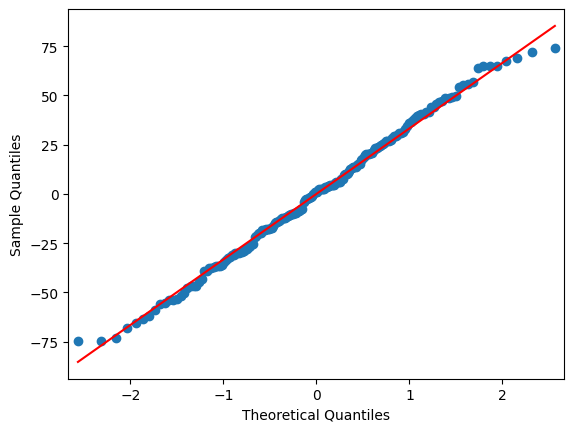

In [100]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [106]:
import pickle

with open('/home/mplitt/shuffle_pkls/licks_sum_mixedlm_shuffle.pkl', 'rb') as file:
    res_dict = pickle.load(file)

In [107]:
res_dict.keys()

dict_keys(['rzone_licks', 'rzone_licks_rank'])

In [114]:
for stat in res_dict.keys():
    coef = res_dict[stat]['genotype coef.']
    shuff_coef = res_dict[stat]['shuffle genotype coef.']

    p = (1.*(coef<shuff_coef)).sum()/shuff_coef.shape[0]
    p = np.minimum(p, 1-p)
    print(f"{stat} : p={p}")

rzone_licks : p=0.018881118881118875
rzone_licks_rank : p=0.019842657342657333
